# Student Performance Analysis and Pass/Fail Prediction
This notebook analyses student performance, creates visualizations,
and builds a logistic regression model to predict pass/fail.

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [41]:
df = pd.read_csv("students.csv")

print("First 5 rows:")
print(df.head())

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [42]:
print("Shape of dataset:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nSummary statistics:")
print(df.describe())
print("\nPass/Fail count:")
print(df['passed'].value_counts())

Shape of dataset: (15, 9)

Data types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary statistics:
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    

In [43]:
subs = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subs].mean(axis=1)
df['overall_avg'] = df[subs].mean(axis=1)
print("Average marks (passed students):")
print(df[df['passed'] == 1][subs].mean())
print("\nAverage marks (failed students):")
print(df[df['passed'] == 0][subs].mean())

# top student

max_index = df['overall_avg'].idxmax()
top = df.loc[max_index]
print("\nTop student based on avg:")
print(top['name'], "->", top['overall_avg'])

Average marks (passed students):
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average marks (failed students):
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64

Top student based on avg:
Diana -> 94.0


In [44]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
print("Average scores for PASS students:")
print(df[df['passed'] == 1][subject_cols].mean())
print("\nAverage scores for FAIL students:")
print(df[df['passed'] == 0][subject_cols].mean())

Average scores for PASS students:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average scores for FAIL students:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [45]:
df['overall_avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['overall_avg'].idxmax()]
print("Top student based on overall average:")
print(top_student['name'], top_student['overall_avg'])

Top student based on overall average:
Diana 94.0


In [46]:
df['avg_score'] = df[subject_cols].mean(axis=1)

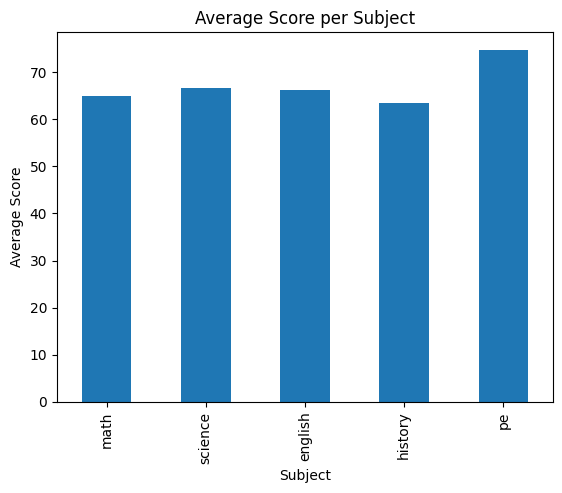

In [47]:
# Bar chart

plt.figure()
df[subject_cols].mean().plot(kind='bar')
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

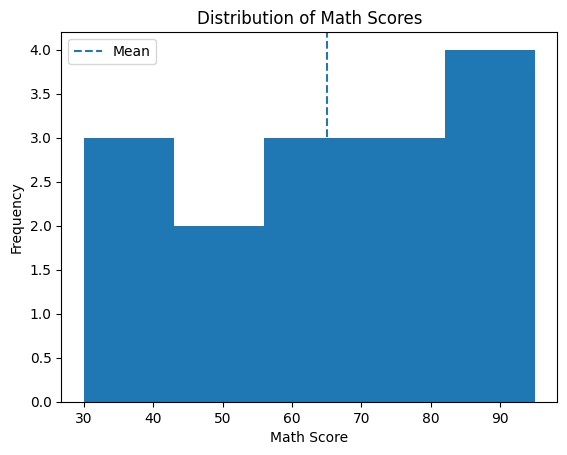

In [48]:
# Histogram

plt.figure()
plt.hist(df['math'], bins=5)
mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label='Mean')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()

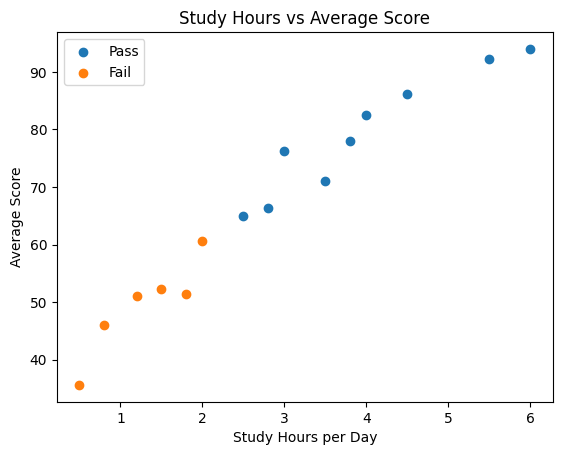

In [49]:
# Scatter plot

plt.figure()
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label='Fail')
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

C:\Users\milir\AppData\Local\Temp\ipykernel_25044\1625639480.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


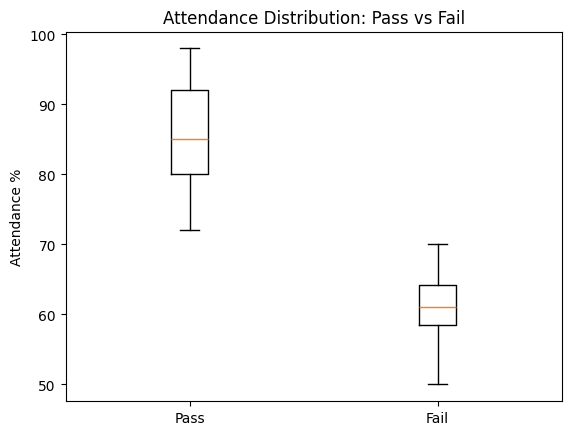

In [50]:
# Box plot

plt.figure()
pass_attendance = df[df['passed']==1]['attendance_pct']
fail_attendance = df[df['passed']==0]['attendance_pct']
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title("Attendance Distribution: Pass vs Fail")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")
plt.show()

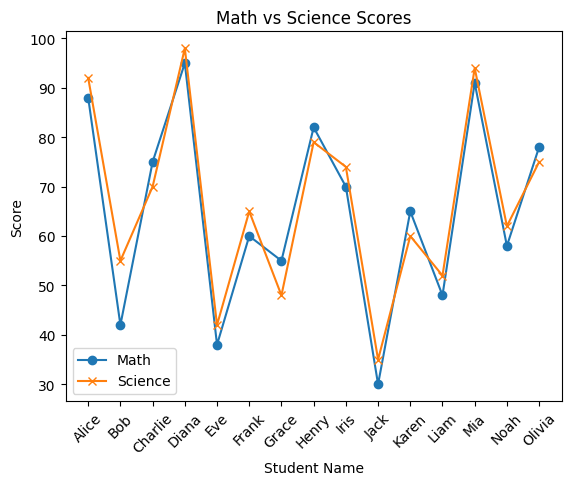

In [51]:
# Line PLot

plt.figure()
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')
plt.xticks(rotation=45)
plt.title("Math vs Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

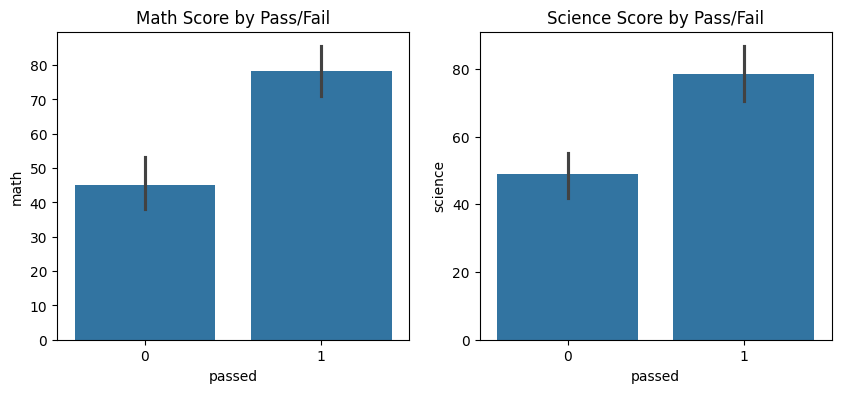

In [52]:
# seaborn bar plot

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Math Score by Pass/Fail")
plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Science Score by Pass/Fail")
plt.savefig("plot6_seaborn_bar.png")
plt.show()

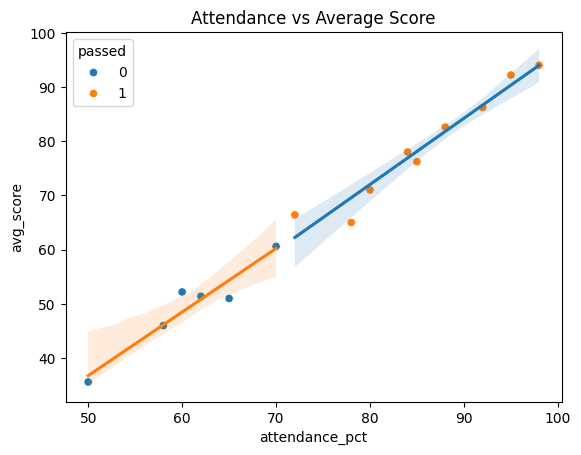

In [53]:
# seaborn scatter

plt.figure()
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', scatter=False)
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', scatter=False)
plt.title("Attendance vs Average Score")
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

Seaborn was easier for grouped and statistical plots like bar plots and regression plots.
Matplotlib required more code but gave more control over plot customization.
Overall, Seaborn is better for quick statistical visualization, while Matplotlib seemed flexible.

In [54]:
# data preperation

features = ['math','science','english','history','pe','attendance_pct','study_hours_per_day']
X = df[features]
y = df['passed']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
print("Training accuracy:", model.score(X_train_scaled, y_train))

Training accuracy: 1.0


In [56]:
pred = model.predict(X_test_scaled)
print("Test accuracy:", accuracy_score(y_test, pred))
names = df.loc[X_test.index, 'name']

for n, actual, predicted in zip(names, y_test, pred):
    if actual == predicted:
        print(n, actual, predicted, "Correct")
    else:
        print(n, actual, predicted, "Wrong")

Test accuracy: 1.0
Jack 0 0 Correct
Liam 0 0 Correct
Alice 1 1 Correct


               Feature  Coefficient
2              english     0.812513
5       attendance_pct     0.521876
6  study_hours_per_day     0.484433
4                   pe     0.474974
0                 math     0.437944
1              science     0.323010
3              history     0.262929


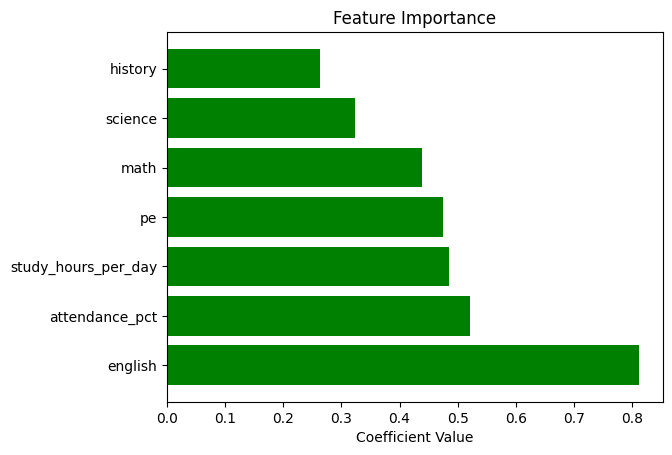

In [57]:
coef = model.coef_[0]

importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': coef
})

importance['abs'] = importance['Coefficient'].abs()
importance = importance.sort_values(by='abs', ascending=False)
print(importance[['Feature','Coefficient']])
plt.figure()
colors = ['green' if x > 0 else 'red' for x in importance['Coefficient']]
plt.barh(importance['Feature'], importance['Coefficient'], color=colors)
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.savefig("feature_importance.png")
plt.show()

In [58]:
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
scaled_new = scaler.transform(new_student)
result = model.predict(scaled_new)
prob = model.predict_proba(scaled_new)

if result[0] == 1:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")

print("Probability:", prob)

Prediction: Pass
Probability: [[0.09203526 0.90796474]]


c:\Users\milir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
